# Máquinas de Vetores de Suporte (SVM)

Material de aula em português para a disciplina de **Mineração de Dados**.


As **Máquinas de Vetores de Suporte** (*Support Vector Machines* — **SVMs**) formam uma classe muito poderosa e flexível de algoritmos supervisionados, usados tanto em **classificação** quanto em **regressão**.

Neste notebook, vamos construir a intuição por trás das SVMs e mostrar como elas podem ser aplicadas em problemas de classificação.

Começamos com os imports padrão:


### Objetivos de aprendizagem

Ao final deste material, você deverá ser capaz de:

- compreender a ideia de **margem máxima**;
- identificar o papel dos **vetores de suporte**;
- entender quando uma **fronteira linear** não é suficiente;
- explicar, intuitivamente, o uso de **kernels**;
- reconhecer o efeito do hiperparâmetro **`C`**;
- aplicar SVM em um exemplo real com **PCA + validação cruzada**.


In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from scipy import stats

## Motivando as Máquinas de Vetores de Suporte


Considere uma tarefa simples de classificação em que duas classes estão bem separadas, como na figura a seguir:


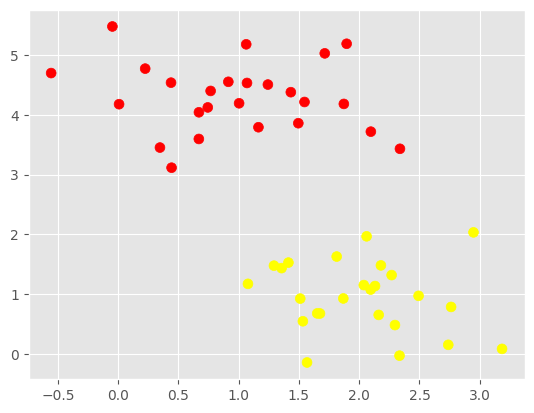

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

Um classificador discriminativo linear tentaria traçar uma reta separando os dois grupos de dados e, com isso, criar um modelo de classificação.

Para dados bidimensionais como os mostrados aqui, até poderíamos fazer isso manualmente.

Mas surge imediatamente um problema: **existe mais de uma reta capaz de separar perfeitamente as duas classes**.

Podemos desenhar algumas dessas retas, como mostrado a seguir:


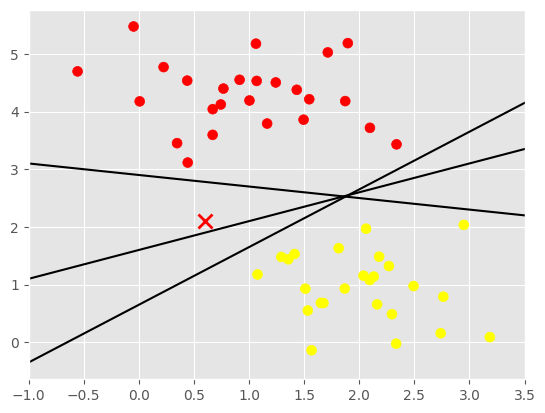

In [ ]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);

Temos aqui três separadores **bem diferentes** que, ainda assim, classificam corretamente essas amostras.

Dependendo de qual reta for escolhida, um novo ponto de dado (por exemplo, o ponto marcado com **X** no gráfico) poderá receber um rótulo diferente.

Fica claro, portanto, que a intuição de “desenhar uma linha entre as classes” não é suficiente. Precisamos de um critério melhor.


## Máquinas de Vetores de Suporte: Maximizando a Margem

As SVMs oferecem uma forma elegante de melhorar essa ideia.

A intuição é a seguinte: em vez de desenhar apenas uma linha sem espessura entre as classes, desenhamos ao redor dessa linha uma **margem** com certa largura, limitada pelos pontos mais próximos.

A ideia é ilustrada a seguir:


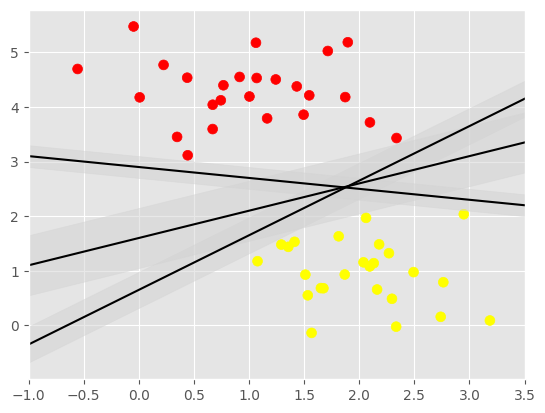

In [ ]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='lightgray', alpha=0.5)

plt.xlim(-1, 3.5);

A reta que **maximiza essa margem** é a que escolhemos como modelo ótimo.


### Ajustando uma Máquina de Vetores de Suporte

Vamos ver o resultado de um ajuste real sobre esses dados.

Usaremos o classificador de vetores de suporte do Scikit-Learn (`SVC`) para treinar um modelo SVM.

Por enquanto, usaremos um **kernel linear** e definiremos o parâmetro `C` com um valor muito alto. Mais adiante discutiremos com mais calma o significado desses parâmetros.


In [ ]:
from sklearn.svm import SVC  # Classificador de vetores de suporte
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

Para visualizar melhor o que está acontecendo, vamos criar uma função auxiliar que desenha, no gráfico, a **fronteira de decisão** da SVM:


In [ ]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plota a função de decisão para uma SVC bidimensional."""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # cria uma grade para avaliar o modelo
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plota a fronteira de decisão e as margens
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plota os vetores de suporte
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, edgecolors='black',
                   facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

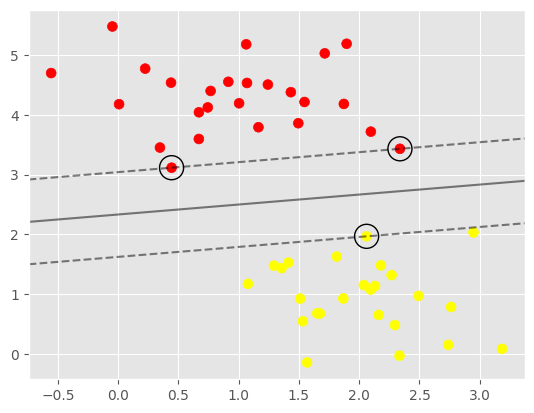

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model);

Essa é a reta que maximiza a margem entre os dois conjuntos de pontos.

Observe que alguns pontos de treinamento tocam exatamente a margem. Eles aparecem destacados na figura.

Esses pontos são os elementos centrais do ajuste e recebem o nome de **vetores de suporte** (*support vectors*), que dão nome ao algoritmo.

No Scikit-Learn, as coordenadas desses pontos ficam armazenadas no atributo `support_vectors_` do classificador:


In [ ]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

Um ponto-chave para o sucesso desse classificador é que, durante o ajuste, **apenas as posições dos vetores de suporte importam**. Pontos mais distantes da margem, desde que estejam do lado correto, não alteram o modelo.

Tecnicamente, isso acontece porque esses pontos não contribuem para a função de perda usada no treinamento. Assim, sua posição e quantidade deixam de importar, desde que não atravessem a margem.

Podemos ver isso, por exemplo, comparando o modelo aprendido com os primeiros 60 pontos e com os primeiros 120 pontos deste conjunto:


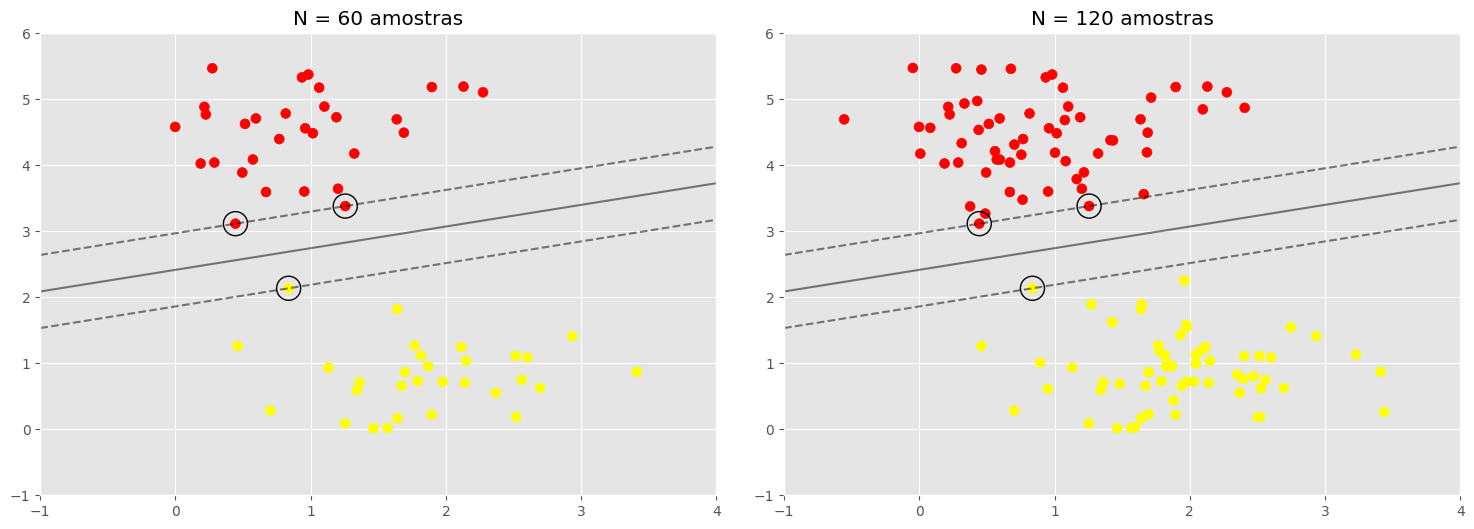

In [ ]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0} amostras'.format(N))

No painel da esquerda, vemos o modelo e os vetores de suporte obtidos com **60 pontos** de treinamento.

No painel da direita, dobramos o número de amostras para **120 pontos**, mas o modelo praticamente não muda: os três vetores de suporte do painel esquerdo continuam sendo os vetores de suporte relevantes no painel direito.

Essa relativa insensibilidade ao comportamento de pontos mais distantes é uma das forças das SVMs.


Se você estiver executando este notebook ao vivo, pode usar os widgets interativos do IPython para observar esse comportamento da SVM dinamicamente:


In [ ]:
from ipywidgets import interact, fixed
interact(plot_svm, N=(10, 200), ax=fixed(None));

interactive(children=(IntSlider(value=10, description='N', max=200, min=10), Output()), _dom_classes=('widget-…

### Indo Além de Fronteiras Lineares: SVM com Kernel

As SVMs se tornam especialmente poderosas quando combinadas com **kernels**.

Para motivar a necessidade de kernels, vamos olhar para um conjunto de dados que **não é linearmente separável**:


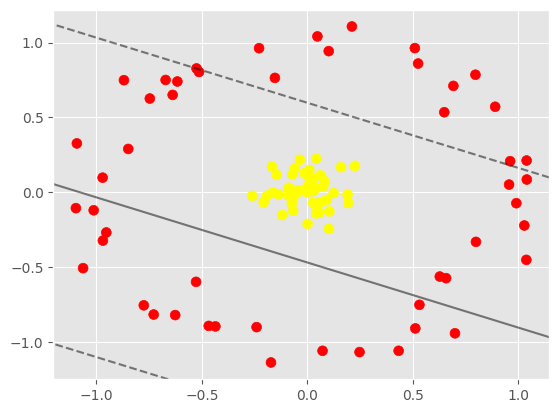

In [ ]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

É claro que nenhuma separação linear será capaz de separar corretamente esses dados.

Mas podemos aproveitar a intuição das funções de base e pensar em como projetar os dados para uma dimensão maior, de forma que um separador linear passe a ser suficiente.

Por exemplo, uma projeção simples seria calcular uma **função de base radial** (*RBF*) centrada no agrupamento do meio:


In [ ]:
r = np.exp(-(X ** 2).sum(1))

Podemos visualizar essa dimensão adicional com um gráfico tridimensional, como a seguir:


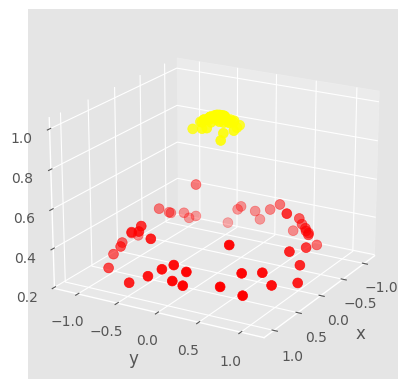

In [ ]:
from mpl_toolkits import mplot3d

ax = plt.subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
ax.view_init(elev=20, azim=30)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('r');

Com essa dimensão extra, os dados passam a ser linearmente separáveis de maneira trivial, por exemplo, usando um plano de separação em torno de **r = 0,7**.

Nesse caso, tivemos que **escolher manualmente** a projeção e ajustá-la com cuidado. Se a função radial não estivesse centrada na região adequada, o resultado não seria tão limpo.

Em geral, essa necessidade de escolher a transformação manualmente é um problema. O ideal seria encontrar automaticamente as melhores funções de base.

Uma estratégia para isso é calcular uma função de base centrada em **cada ponto do conjunto de dados** e deixar que o algoritmo da SVM selecione o que é mais relevante.

Esse tipo de transformação é conhecido como **transformação por kernel**, pois se baseia em uma medida de similaridade entre pares de pontos.

Um possível problema dessa estratégia é o custo computacional: projetar **N pontos em N dimensões** pode se tornar caro quando N cresce.

No entanto, graças ao chamado [*truque do kernel*](https://en.wikipedia.org/wiki/Kernel_trick), esse ajuste pode ser feito de forma implícita, isto é, **sem construir explicitamente** toda a representação em dimensão elevada.

Esse truque está embutido nas SVMs e é uma das razões pelas quais o método é tão poderoso.

No Scikit-Learn, podemos aplicar uma SVM com kernel simplesmente trocando o kernel linear por um kernel RBF:


In [ ]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

Vamos usar a função que definimos anteriormente para visualizar o ajuste e identificar os vetores de suporte:


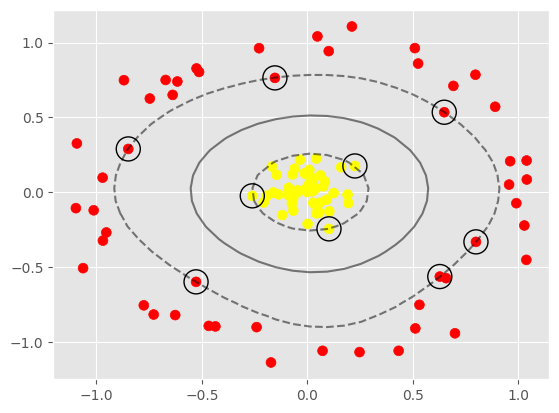

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

Com essa SVM com kernel, aprendemos uma **fronteira de decisão não linear** adequada ao problema.

Essa estratégia de transformação por kernel é bastante usada em aprendizado de máquina para transformar métodos lineares rápidos em métodos não lineares também eficientes, especialmente quando o truque do kernel pode ser aplicado.


### Ajustando a SVM: Suavizando a Margem

Até aqui, nossa discussão se concentrou em conjuntos de dados bem “limpos”, nos quais existe uma fronteira de decisão perfeita.

Mas o que acontece quando os dados apresentam **sobreposição entre classes**?

Por exemplo, podemos ter algo como o conjunto a seguir:


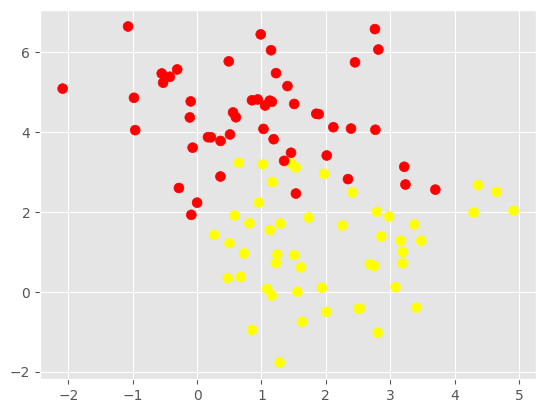

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

Para lidar com esse caso, a implementação da SVM introduz um mecanismo que **suaviza a margem**. Em outras palavras, ela permite que alguns pontos entrem na margem quando isso leva a um ajuste melhor.

A rigidez dessa margem é controlada pelo parâmetro `C`.

- Para valores **muito altos** de `C`, a margem é mais rígida e os pontos praticamente não podem invadi-la.
- Para valores **menores** de `C`, a margem fica mais flexível e pode acomodar alguns pontos.

A figura a seguir mostra visualmente como a mudança em `C` afeta o ajuste final:


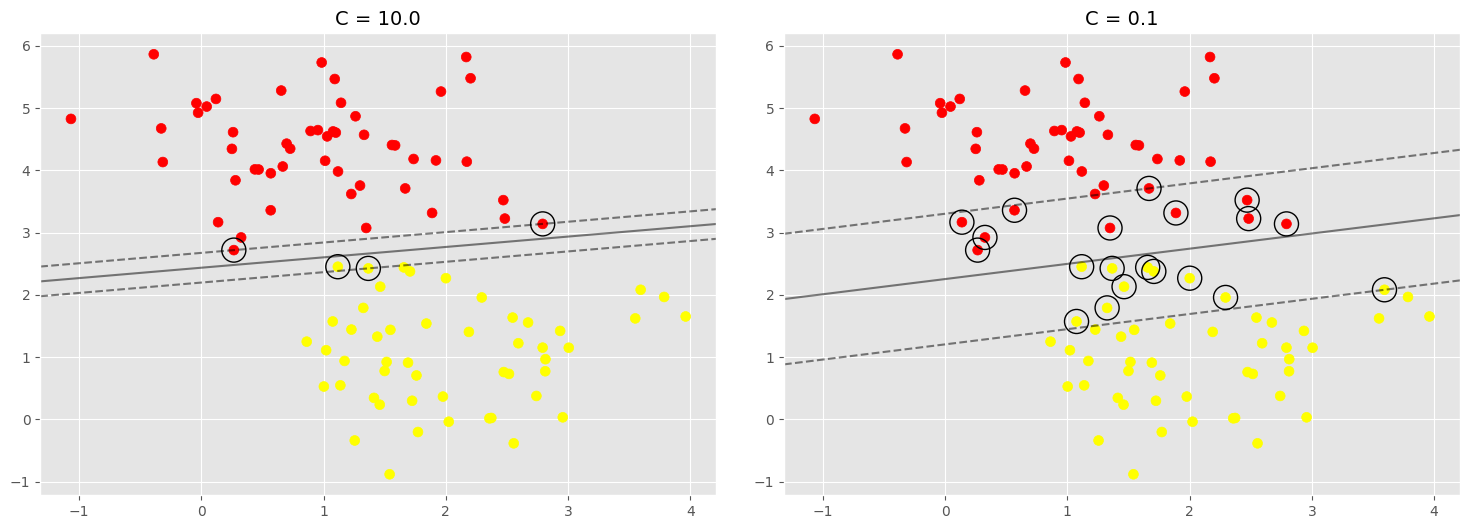

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

O valor ótimo de `C` depende do seu conjunto de dados e deve ser ajustado usando **validação cruzada** ou algum procedimento semelhante (veja também [Hiperparâmetros e Validação de Modelos](05.03-Hyperparameters-and-Model-Validation.ipynb)).


## Exemplo: Reconhecimento Facial

Como exemplo de SVM em ação, vamos analisar um problema de **reconhecimento facial**.

Usaremos o conjunto **Labeled Faces in the Wild**, que reúne milhares de fotos de figuras públicas.

O Scikit-Learn já possui um carregador para esse dataset.

> **Observação:** na primeira execução, pode ser necessário baixar o conjunto de dados da internet.


In [ ]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Vamos visualizar algumas dessas faces para entender melhor com que tipo de dado estamos trabalhando:


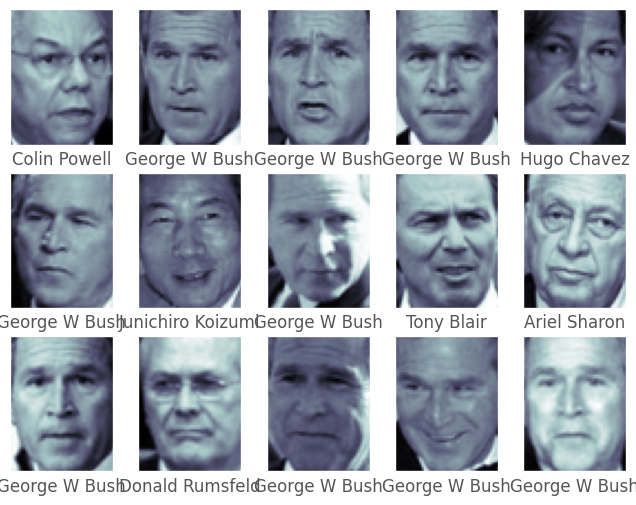

In [ ]:
fig, ax = plt.subplots(3, 5, figsize=(8, 6))
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

Cada imagem possui **62 × 47 pixels**, ou seja, cerca de **3.000 atributos**.

Poderíamos usar diretamente o valor de cada pixel como característica, mas em muitos casos é mais eficiente aplicar algum pré-processamento para extrair atributos mais informativos.

Aqui usaremos **Análise de Componentes Principais (PCA)** (veja [Em Profundidade: Análise de Componentes Principais](05.09-Principal-Component-Analysis.ipynb)) para extrair **150 componentes principais** e fornecê-los ao classificador SVM.

A forma mais prática de fazer isso é empacotar o pré-processamento e o classificador em um único **pipeline**:


In [ ]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

pca = PCA(n_components=150, whiten=True,
          svd_solver='randomized', random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

Para avaliar o desempenho do classificador, vamos dividir os dados em **treinamento** e **teste**:


In [ ]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,
                                                random_state=42)

Agora podemos usar **busca em grade com validação cruzada** (*grid search cross-validation*) para explorar combinações de parâmetros.

Aqui ajustaremos:

- `C`, que controla a rigidez da margem;
- `gamma`, que controla a largura efetiva do kernel de base radial.

Com isso, encontraremos o melhor modelo:


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

CPU times: user 2min 9s, sys: 346 ms, total: 2min 9s
Wall time: 1min 18s
{'svc__C': 5, 'svc__gamma': 0.001}


Os valores ótimos aparecem no meio da grade de busca. Se estivessem nas extremidades, seria recomendável expandir a grade para verificar se realmente encontramos o melhor ponto.

Com o modelo ajustado via validação cruzada, podemos agora prever os rótulos dos dados de teste, que ainda não foram vistos pelo modelo:


In [ ]:
model = grid.best_estimator_
yfit = model.predict(Xtest)

Vamos observar algumas imagens do conjunto de teste junto com as previsões do modelo:


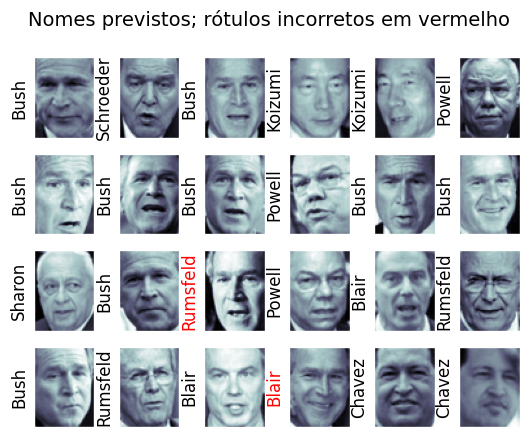

In [ ]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Nomes previstos; rótulos incorretos em vermelho', size=14);

Nesse pequeno conjunto de exemplos, o melhor estimador errou apenas uma face (a imagem de Bush na última linha foi classificada como Blair).

Podemos entender melhor o desempenho do modelo usando o **relatório de classificação**, que apresenta métricas por classe:


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



Também podemos exibir a **matriz de confusão** entre as classes:


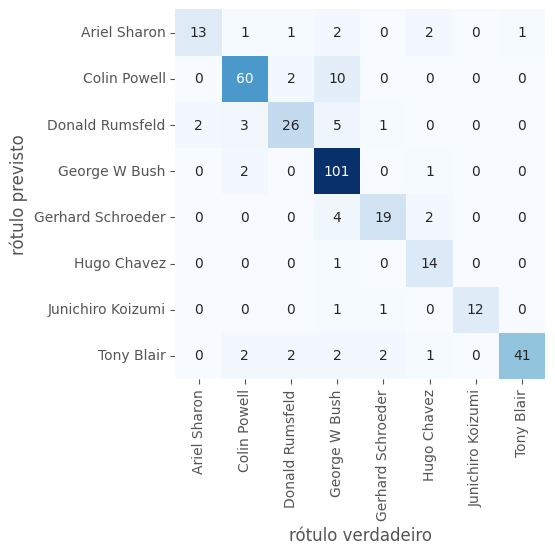

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d',
            cbar=False, cmap='Blues',
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('rótulo verdadeiro')
plt.ylabel('rótulo previsto');

Isso ajuda a identificar quais rótulos têm maior probabilidade de serem confundidos pelo estimador.

Em uma tarefa real de reconhecimento facial, em que as fotos não chegam previamente recortadas e alinhadas, a principal diferença estaria na etapa de **extração de características**: seria necessário usar um algoritmo mais sofisticado para localizar as faces e extrair atributos robustos à pixelização e a variações de pose, iluminação etc.

Para esse tipo de aplicação, uma boa opção é usar o [OpenCV](http://opencv.org), que oferece implementações pré-treinadas de métodos modernos de extração de características para imagens em geral e faces em particular.




---



Amostra do dataset:


,texto,classe
0,"Gostei muito do produto, a qualidade é excelente",positivo
1,Entrega rápida e atendimento muito bom,positivo
2,"Aplicativo ótimo, fácil de usar e muito útil",positivo
3,"Restaurante maravilhoso, comida deliciosa",positivo
4,"Experiência excelente, recomendo para todos",positivo


Quantidade de textos de treino: 16
Quantidade de textos de teste: 8
\nAcurácia no teste: 0.375
\nRelatório de classificação:
              precision    recall  f1-score   support

    negativo       0.33      0.25      0.29         4
    positivo       0.40      0.50      0.44         4

    accuracy                           0.38         8
   macro avg       0.37      0.38      0.37         8
weighted avg       0.37      0.38      0.37         8



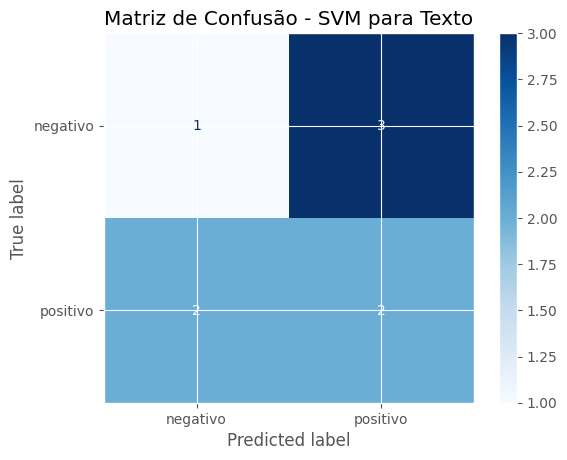

\nClasses encontradas: ['negativo', 'positivo']


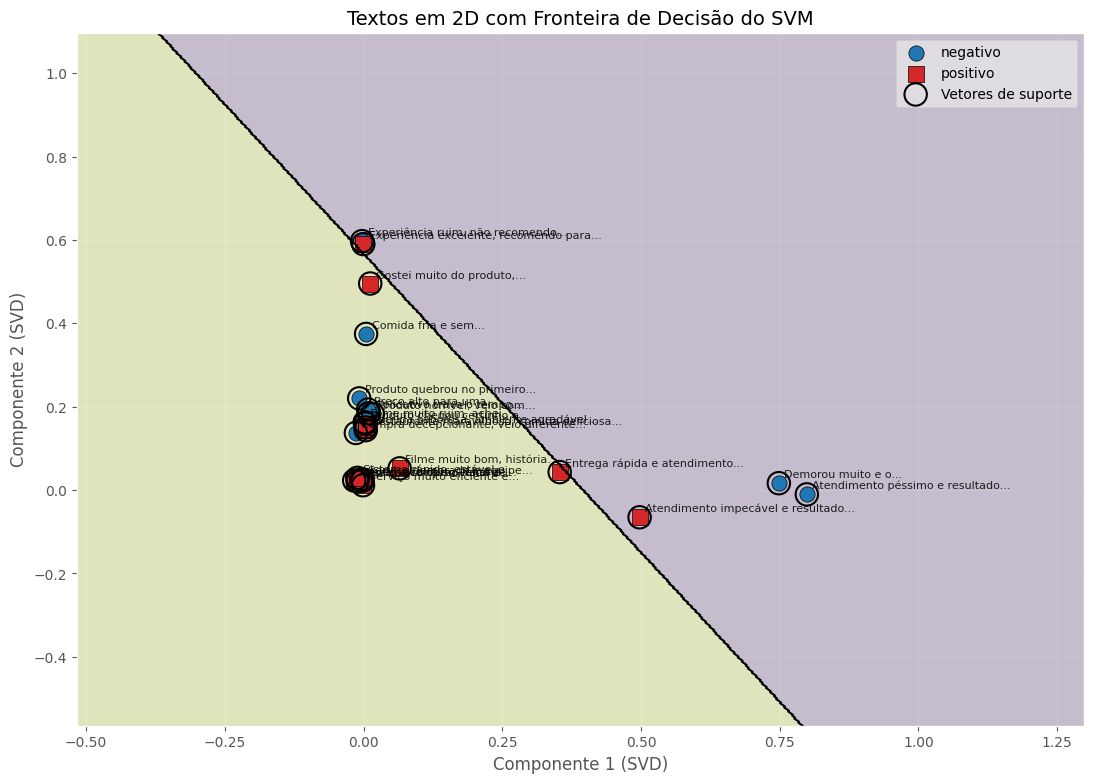

In [ ]:
# ============================================================
# SVM para classificação de textos em português
# + visualização dos textos como pontos em 2D
# + fronteira de decisão do SVM
# ============================================================

# ---------------------------
# 1. Importação das bibliotecas
# ---------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# ---------------------------
# 2. Dataset de exemplo em português
#    (Você pode substituir pelos seus próprios dados)
# ---------------------------
textos = [
    "Gostei muito do produto, a qualidade é excelente",
    "Entrega rápida e atendimento muito bom",
    "Aplicativo ótimo, fácil de usar e muito útil",
    "Restaurante maravilhoso, comida deliciosa",
    "Experiência excelente, recomendo para todos",
    "Serviço muito eficiente e equipe educada",
    "Produto chegou certinho e funcionou perfeitamente",
    "Adorei a compra, voltarei a comprar novamente",
    "Sistema rápido, estável e muito prático",
    "Filme muito bom, história envolvente e emocionante",
    "Atendimento impecável e resultado fantástico",
    "Comida saborosa, ambiente agradável e preço justo",

    "Produto horrível, veio com defeito",
    "Demorou muito e o atendimento foi péssimo",
    "Aplicativo trava o tempo todo, muito ruim",
    "Comida fria e sem sabor, não gostei",
    "Experiência ruim, não recomendo",
    "Serviço demorado e equipe despreparada",
    "Compra decepcionante, veio diferente do anunciado",
    "Sistema confuso, lento e cheio de erros",
    "Filme muito ruim, achei cansativo e chato",
    "Atendimento péssimo e resultado insatisfatório",
    "Preço alto para uma qualidade tão baixa",
    "Produto quebrou no primeiro uso, muito decepcionante"
]

rotulos = [
    "positivo","positivo","positivo","positivo","positivo","positivo",
    "positivo","positivo","positivo","positivo","positivo","positivo",
    "negativo","negativo","negativo","negativo","negativo","negativo",
    "negativo","negativo","negativo","negativo","negativo","negativo"
]

df = pd.DataFrame({
    "texto": textos,
    "classe": rotulos
})

print("Amostra do dataset:")
display(df.head())

# ---------------------------
# 3. Função simples de limpeza textual
# ---------------------------
def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\\S+|www\\S+", " ", texto)       # remove URLs
    texto = re.sub(r"[^a-zà-úâêîôûãõç\\s]", " ", texto)   # mantém letras e espaços
    texto = re.sub(r"\\s+", " ", texto).strip()           # remove espaços extras
    return texto

# Pequena lista de stopwords em português
stopwords_pt = [
    "a", "o", "as", "os", "um", "uma", "uns", "umas",
    "de", "da", "do", "das", "dos",
    "em", "no", "na", "nos", "nas",
    "para", "por", "com", "sem",
    "e", "ou", "mas",
    "que", "como", "muito", "muita", "muitos", "muitas",
    "é", "foi", "ser", "ter"
]

# ---------------------------
# 4. Divisão em treino e teste
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df["texto"],
    df["classe"],
    test_size=0.30,
    random_state=42,
    stratify=df["classe"]
)

print(f"Quantidade de textos de treino: {len(X_train)}")
print(f"Quantidade de textos de teste: {len(X_test)}")

# ---------------------------
# 5. Pipeline de classificação textual com TF-IDF + SVM
# ---------------------------
modelo_texto = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=limpar_texto,
        stop_words=stopwords_pt,
        ngram_range=(1, 2),   # usa unigramas e bigramas
        min_df=1
    )),
    ("svm", SVC(kernel="linear", C=1.0))
])

# Treinamento
modelo_texto.fit(X_train, y_train)

# Predição
y_pred = modelo_texto.predict(X_test)

# ---------------------------
# 6. Avaliação do modelo
# ---------------------------
print("\\nAcurácia no teste:", round(accuracy_score(y_test, y_pred), 4))
print("\\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=modelo_texto.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_texto.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - SVM para Texto")
plt.show()

# ---------------------------
# 7. Vetorização de TODOS os textos para visualização
#    Aqui usamos o dataset todo apenas para fins didáticos
# ---------------------------
vectorizer_vis = TfidfVectorizer(
    preprocessor=limpar_texto,
    stop_words=stopwords_pt,
    ngram_range=(1, 2),
    min_df=1
)

X_tfidf = vectorizer_vis.fit_transform(df["texto"])

# Redução para 2 dimensões
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

# Codificação dos rótulos para números
label_encoder = LabelEncoder()
y_num = label_encoder.fit_transform(df["classe"])

print("\\nClasses encontradas:", list(label_encoder.classes_))

# ---------------------------
# 8. Treinamento de um segundo SVM em 2D
#    Este modelo é APENAS para visualização
# ---------------------------
modelo_2d = SVC(kernel="linear", C=1.0)
modelo_2d.fit(X_2d, y_num)

# ---------------------------
# 9. Função para plotar os pontos e a fronteira de decisão
# ---------------------------
def plotar_fronteira_svm_2d(X, y, textos, modelo, classes):
    # Limites do gráfico
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Grade para desenhar a fronteira
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    pontos_grade = np.c_[xx.ravel(), yy.ravel()]
    Z = modelo.predict(pontos_grade)
    Z = Z.reshape(xx.shape)

    # Plot da região de decisão
    plt.figure(figsize=(13, 9))
    plt.contourf(xx, yy, Z, alpha=0.20)
    plt.contour(xx, yy, Z, colors="black", linewidths=0.7, alpha=0.7)

    # Cores e marcadores
    cores = ["tab:blue", "tab:red", "tab:green", "tab:purple", "tab:orange"]
    marcadores = ["o", "s", "^", "D", "P"]

    # Plot dos pontos
    for classe_id, classe_nome in enumerate(classes):
        idx = np.where(y == classe_id)[0]

        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=cores[classe_id % len(cores)],
            marker=marcadores[classe_id % len(marcadores)],
            s=120,
            edgecolors="black",
            label=classe_nome
        )

        # Anotação com um trecho do texto
        for i in idx:
            trecho = " ".join(textos[i].split()[:4]) + "..."
            plt.annotate(
                trecho,
                (X[i, 0], X[i, 1]),
                fontsize=8,
                alpha=0.85,
                xytext=(4, 4),
                textcoords="offset points"
            )

    # Destacar vetores de suporte
    suportes = modelo.support_vectors_
    plt.scatter(
        suportes[:, 0],
        suportes[:, 1],
        s=260,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="Vetores de suporte"
    )

    plt.title("Textos em 2D com Fronteira de Decisão do SVM", fontsize=14)
    plt.xlabel("Componente 1 (SVD)")
    plt.ylabel("Componente 2 (SVD)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# ---------------------------
# 10. Geração do gráfico final
# ---------------------------
plotar_fronteira_svm_2d(
    X=X_2d,
    y=y_num,
    textos=df["texto"].tolist(),
    modelo=modelo_2d,
    classes=label_encoder.classes_
)

## Resumo

Esta foi uma introdução breve, mas intuitiva, aos princípios das **Máquinas de Vetores de Suporte**.

As SVMs são um método de classificação muito poderoso por vários motivos:

- Dependem de relativamente poucos vetores de suporte, o que as torna compactas e econômicas em memória.
- Depois de treinado, o modelo costuma realizar previsões rapidamente.
- Como são influenciadas principalmente por pontos próximos da margem, funcionam bem em dados de alta dimensionalidade — inclusive em situações com mais atributos do que amostras.
- A integração com métodos de kernel as torna bastante versáteis, permitindo adaptação a vários tipos de dados.

Por outro lado, as SVMs também apresentam algumas limitações:

- O custo computacional cresce de forma significativa com o número de amostras. Em conjuntos muito grandes, o treinamento pode se tornar caro.
- O resultado depende fortemente de uma boa escolha do parâmetro `C`, que normalmente precisa ser ajustado com validação cruzada.
- As previsões não possuem interpretação probabilística direta. Isso pode ser estimado internamente (por exemplo, com o parâmetro `probability` do `SVC`), mas com custo computacional adicional.

Em termos práticos, as SVMs costumam ser especialmente úteis quando métodos mais simples não entregam o desempenho desejado e quando o problema exige uma fronteira de decisão mais sofisticada.
